# Sztuczna inteligencja i inżynieria wiedzy - Raport 1

## 1. Wstęp

### 1.1. Wczytywanie danych

Pierwszym krokiem do utworzenia poprawnego grafu było prawidłowe wczytanie danych. Każdy dzień w rozkładzie jazdy może mieć dodane lub usunięte kursy. Po wczytaniu danych za pomocą funkcji `load_data` z klasy `GTFSLoader`, dane są przygotowywane do stworzenia z nich grafu. Funkcja `get_active_services_for_date` filtruje dane i zwraca rzeczywiście aktywne w danym dniu kursy, wykorzystując operacje na zbiorach:

```python
    base_services = set(self.calendar.loc[base_services_conditions, 'service_id'])

    exceptions_today = self.calendar_dates[self.calendar_dates['date'] == date_int]
    added_services = set(exceptions_today[exceptions_today['exception_type'] == 1]['service_id'])
    removed_services = set(exceptions_today[exceptions_today['exception_type'] == 2]['service_id'])
                
    active_services = (base_services | added_services) - removed_services
```

### 1.2. Budowa grafu

Założyłem, że graf będzie się składać z wierzchołków oraz dwóch typów krawędzi. Rozróżniam krawędzie między róznymi stacjami (peronami różnych stacji) oraz krawędzie między peronami tej samej stacji (również stacja nadrzędna - peron). Graf w wykorzystanych algorytmach może być zależny od czasu lub liczby przesiadek. Fragment metody `build_graph` klasy `Graph`:

```python
    self.__build_nodes(stops_df)
    self.__build_trip_edges(stop_times_df)
    self.__build_transfer_edges(stops_df)
```

Graf składa się z elementów klasy `Node`, które posiadają poniższa strukturę:

```python
    @dataclass
    class Node:
        stop_id: str
        name: str
        lat: float
        lon: float
        parent_station: str
        platform: str
        edges: list[Edge] = field(default_factory=list)
        
        def add_edge(self, edge: Edge) -> None:
            self.edges.append(edge)
    @dataclass
    class Edge:
        target_id: str
        route_name: str
        trip_id: Optional[str]
        departure_time: Optional[pd.Timedelta]
        arrival_time: Optional[pd.Timedelta]
```

## 2. Algorytmy

### 2.1. Opis
W problemie wyznaczania optymalnych połączeń komunikacyjnych, sieć transportowa reprezentowana jest jako graf skierowany, gdzie węzły stanowią przystanki, a krawędzie reprezentują fizyczne połączenia między nimi, obciążone wagą zależną od czasu lub ilości przesiadek w trakcie trasy. 

Algorytm Dijkstry jest klasycznym podejściem do wyznaczania najkrótszej ścieżki z jednego źródła w grafie, utrzymuje zbiór odwiedzonych wierzchołków oraz dynamicznie aktualizowaną tablicę najmniejszych kosztów dotarcia ze źródła. Algorytm przeszukuje graf równomiernie we wszystkich kierunkach, co prowadzi do sprawdzania wielu węzłów, które geograficznie oddalają się od celu.

Algorytm A* jest rozszerzeniem Dijkstry o mechanizm heurystyki. Wprowadza on funkcję celu, która decyduje o kolejności eksploracji węzłów: $f(n) = g(n) + h(n)$, gdzie: $g(n)$ - rzeczywisty koszt oraz $h(n)$ - heurystyka, czyli szacowany koszt. Heurystyka powinna być dopuszczalna, czyli nigdy nie przeszacowywać rzeczywistego kosztu do celu. W nawigacji najczęściej stosuje się heurystykę związaną z odległością w linii prostej - euklidesowa lub Haversine. Korzystając z współrzędnych geograficznych dla większej dokładności warto użyć metody Haversine - jest to spoób na obliczenie odległości od siebie dwóch punktów na powierzchni sfery, zatem uwzględnia krzywiznę Ziemi.

W kontekście danych GTFS, główną różnicą między algorytmami jest obszar poszukiwań. Dijkstra tworzy koło wokół punktu startowego, natomiast A* jest skierowany ku celowi. Warto zauważyć, jeśli $h(n) = 0$, algorytm A* staje się tożsamy z algorytmem Dijkstry.

### 2.2. Implementacja
Do rozwiązania zadania podszedłem w sposób obiektowy. Implementacja algorytmów przeszukujących jest realizowana przez klasę `PathFinder`. Posiada ona funkcję opakowującą - `find_shortest_path_astar`, która pozwala na wybór sposobu optymalizacji (kryterium czasu lub liczby przesiadek). Algorytm Dijsktra i A* oparłem na jednej funkcji - `__shortest_path_engine`. Funkcja przyjmuje argument `use_astar`, dzięki czemu stosuje odpowiednie wartości heurystyk (dla Dijsktra równe 0). Poniżej opis kilku kluczowych fragmentów metody `__shortest_path_engine`:

```python
    start_key = self.__get_node_key(start_stop_id, None, optimize_for)
    h_score = self.__heuristic(self.graph.nodes[start_stop_id], target_node, optimize_for) if use_astar else 0
        
    heapq.heappush(priority_queue, self.__build_priority_tuple(optimize_for, start_time, start_transfers, h_score, counter, start_stop_id, None))
```
W trybie `use_astar` do węzła dodawana jest wartość heurystyki `h_score`, dodatkowo istotną rolę pełni funkcja `__get_node_key`, która zwraca postać klucza - węzła w zależności od tego, co jest optymalizowane (id węzła dla czasu oraz krotkę składającą się z id węzła oraz `trip_id`):

```python
    @staticmethod
    def __get_node_key(node_id: str, trip_id: Optional[str], optimize_for: str) -> Any:
        return (node_id, trip_id) if optimize_for == 'p' else node_id
```
W zależności od trybu optymalizacji zmienia się również krotka pełniąca funkcję kryterium priorytetu w kolejce priorytetowej niezbędnej do realizacji algorytmu przeszukującego, ciało metody `__build_priority_tuple`:

```python
    if optimize_for == 't':
        priority_score = current_time + h_score if h_score else current_time
        secondary_score = transfers
    else:
        priority_score = transfers + h_score if h_score else transfers
        secondary_score = current_time
            
    return (priority_score, secondary_score, counter, current_time, transfers, node_id, trip_id)
```
Po ustaleniu obecności i ewentualnie typu heurystyki oraz przygtowaniu kolejki priorytetowej, algorytm działa dopóki kolejka priorytetowa nie stanie się pusta - wtedy jeśli pobrany z niej węzeł to przystanek docelowy, następuję rekonstrukcja trasy za pomocą prostej metody `__reconstruct_path`, która odwzorowuje trasę na podstawie słownika `came_from` aktualizowanego podczas działania algorytmu:

```python
    if cost_to_compare < best_known_cost:
        distances[next_key] = cost_to_compare
        came_from[next_key] = (current_key, edge, next_time, dep_time)
```

Kolejnym istotnym fragmentem funkcji `__shortest_path_engine` jest proces relaksacji krawędzi. Algorytm odrzuci te odjazdy pociągów, na które jest już spóźniony, to znaczy - czas odjazdu pociągu jest wcześniej niż obecny czas. Odrzuci również te pociągi, na które trzeba czekać dłużej niż warotść opcjonalnego argumentu `max_wait_time`, który może podać użytkownik. W szczególnym przypadku może to doprowadzić do szukania trasy zakończonego niepowodzeniem, lecz w większości przypadków znacznie przyspiesza to działanie algorytmu poprzez zawężenie grafu. Fragment kodu odpowiadający za relaksację krawędzi:

```python
    if edge.departure_time < current_time:
        continue
    wait_time = edge.departure_time - current_time
    if max_wait_time is not None and wait_time > max_wait_time:
        continue
```

Aby algorytm A* stał się ulepszeniem algorytmu Dijkstry należało stworzyć pewne heurystyki. Pierwsza heurystyka optymalizuje zależnie od czasu, druga od liczby przesiadek. Obie oparłem na metodzie Haversine. Heurystyka czasowa zwraca odległość w linii prostej liczoną za pomocą wzoru Haversine dzieloną przez średnią prędkość pociągu, przyjętą jako 150 km\h. W heurystyce przesiadkowej odległość Haversine jest dzielona przez średnią wartością trasy Kolei Dolnośląskich, przyjętą jako 100km. Jednak usprawnieniem jest to, że jeśli przystanek początkowy i końcowy w swoich rozkładach posiadają tę samą linię, co oznacza że istnieje bezpośrednie połączenie, to heurystyka ta wyniesie 0. Poniżej kod funkcji heurystyki:

```python
    def __heuristic(self, node1: Node, node2: Node, optimize_for: str = 't') -> pd.Timedelta | int:
        lat1, lon1 = math.radians(node1.lat), math.radians(node1.lon)
        lat2, lon2 = math.radians(node2.lat), math.radians(node2.lon)
        dLat, dLon = lat2 - lat1, lon2 - lon1

        a = math.sin(dLat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dLon / 2)**2
        c = 2 * math.asin(math.sqrt(a))
        distance_km = EARTH_RADIUS * c
        
        if optimize_for == 't':
            hours = distance_km / TRAIN_SPEED
            return pd.Timedelta(hours=hours)
        else:
            routes_curr = self.stop_to_routes.get(node1.stop_id, set())
            routes_target = self.stop_to_routes.get(node2.stop_id, set())
            
            if not routes_curr.isdisjoint(routes_target):
                return 0
            
            transfers = math.floor(distance_km / TRAIN_MAX_DISTANCE)
            return transfers
```

## 3. Przykładowe wyniki

### 3.1. Dane
- stacja początkowa: 1413213 (Leszno Górne)
- stacja końcowa: 1413398 (Wrocław Stadion)
- czas rozpoczęcia: 12:00

### 3.2. Optymalizacja względem czasu
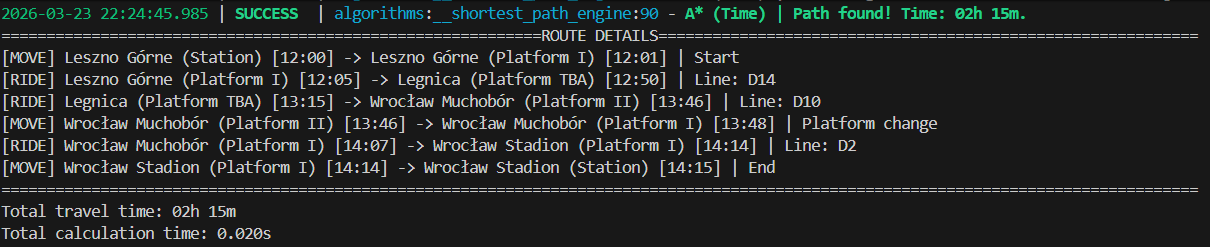
### 3.3. Optymalizacja względem liczby przesiadek
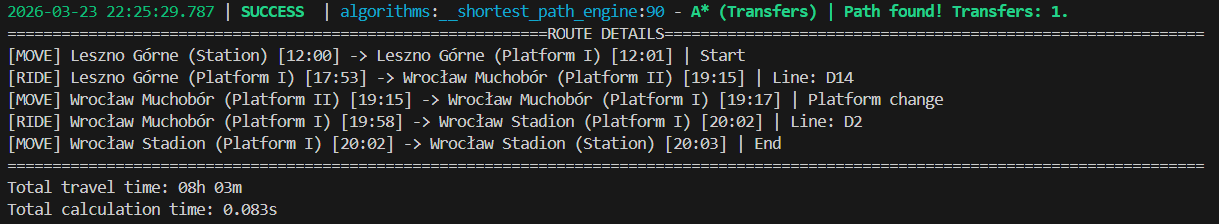

Widać wyraźnie różnicę w wynikach - optymalizacja względem czasu zwraca czas całej podróży równy lekko ponad 2 godziny, ale zakłada dwie przesiadki. Optmyalizując względem liczby przesiadek, czas wydłuża się do 8 godzin, ale za to przesiadka jest tylko jedna.

## 4. Podsumowanie

### 4.1. Problemy
- Perony z pustą wartością `platform_code`:
  
    Większość danych przystanków na danej stacji to stacja nadrzędna oraz perony z poprawnym kodem. Jednak pojawiają się perony, które tej wartośći nie mają podanej. Przyjąłem, że są to perony "ruchome" - zależne od obłożenia peronów na stacji w danym momencie. Podczas zwracania wyniku trasy określam taki peron jako "TBA" ("To Be Announced).

- Przekraczanie północy:

    W mojej implementacji niemożliwe jest zrobienie przesiadki na inny kurs, jeśli odbywa się on w innym dniu. Co prawda, możliwe jest rozpoczęcie trasy jednego dnia i zakończenie dnia następnego, ale jedynie pod warunkiem, że jeden z kursów całej podróży przekracza północ. Dzieje się tak, ponieważ przed stworzeniem grafu filtruje dane, tak aby zostały tylko kursy aktywne w danym dniu. Możliwym rozwiązaniem jest filtrowanie np. obecny dzień i następny, ale wtedy wykluczam wycieczki 3 dniowe (zatem zawsze będzie wykluczony następny dzień po liczbie dopuszczalnych dni)

### 4.2 Użyte biblioteki
- pandas - wczytywanie, filtrowanie danych oraz działania na zbiorach
- loguru - czytelne logowanie w konsoli
- heapq - struktura kopca binarnego realizującego kolejkę priorytetową
- math - obliczenia we wzorze Haversine
- argparse - wczytywanie danych od użytkownika
  
### 4.3. Wykaz źródeł
- instrukcja laboratoryjna i załączona w niej bibliografia
- materiały z wykładu
- https://www.youtube.com/watch?v=EFg3u_E6eHU
- https://www.geeksforgeeks.org/dsa/dijkstras-shortest-path-algorithm-using-priority_queue-stl/
- https://www.geeksforgeeks.org/dsa/haversine-formula-to-find-distance-between-two-points-on-a-sphere/
- Gemini 3.1 Pro

### 4.4. Użycie sztucznej inteligencji
- funkcja wyświetlająca wyniki - `print_trip`
- skrypt wczytujący dane od użytkownika - `input_handler.py`
- skrypt ładujący dane GTFS - `gtfs_loader.py`
- fragmenty funkcji, na której opiera się przeszukiwanie - `__shortest_path_engine`

Kody wygenerowane za pomocą sztucznej inteligencji końcowo zostały przeredagowane pod moje preferencje oraz potrzeby rozwiązania.